In [39]:
import pandas as pd
df=pd.read_csv("titanic.csv",usecols=["Age","Fare","Sex","sibsp","Embarked","Parch","Pclass","2urvived"])

In [40]:
df.columns

Index(['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked',
       '2urvived'],
      dtype='object')

In [41]:
df.rename(columns={'2urvived': 'survived'}, inplace=True)

In [42]:
df.shape

(1309, 8)

In [43]:
df.sample(10)

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,survived
291,19.0,91.0792,1,1,0,1,0.0,1
880,25.0,26.0000,1,0,1,2,2.0,1
1263,49.0,0.0000,0,0,0,1,2.0,0
621,42.0,52.5542,0,1,0,1,2.0,1
275,63.0,77.9583,1,1,0,1,2.0,1
394,24.0,16.7000,1,0,2,3,2.0,1
290,26.0,78.8500,1,0,0,1,2.0,1
726,30.0,21.0000,1,3,0,2,2.0,1
1262,31.0,134.5000,1,0,0,1,0.0,0
877,19.0,7.8958,0,0,0,3,2.0,0


In [44]:
df.dtypes

Age         float64
Fare        float64
Sex           int64
sibsp         int64
Parch         int64
Pclass        int64
Embarked    float64
survived      int64
dtype: object

In [45]:
df.describe()

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1307.000000,1309.000000
mean,29.503186,33.281086,0.355997,0.498854,0.385027,2.294882,1.492731,0.261268
std,12.905241,51.741500,0.478997,1.041658,0.865560,0.837836,0.814626,0.439494
min,0.170000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,22.000000,7.895800,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000
75%,35.000000,31.275000,1.000000,1.000000,0.000000,3.000000,2.000000,1.000000
max,80.000000,512.329200,1.000000,8.000000,9.000000,3.000000,2.000000,1.000000


In [46]:
df.isnull().sum()

Age         0
Fare        0
Sex         0
sibsp       0
Parch       0
Pclass      0
Embarked    2
survived    0
dtype: int64

In [ ]:
#Filling nulls
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [48]:
df.isnull().sum()

Age         0
Fare        0
Sex         0
sibsp       0
Parch       0
Pclass      0
Embarked    0
survived    0
dtype: int64

<Axes: ylabel='Density'>

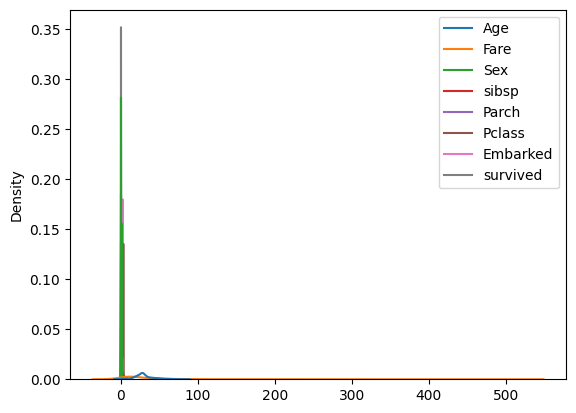

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df)

In [50]:
from sklearn.preprocessing import LabelEncoder
oe= LabelEncoder()
df['Embarked']=oe.fit_transform(df['Embarked'])

In [51]:
df.columns

Index(['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked',
       'survived'],
      dtype='object')

In [52]:
df['Sex']=oe.fit_transform(df['Sex'])

In [53]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df[[ 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked']] = sc.fit_transform(df[[ 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked']])

<Axes: ylabel='Density'>

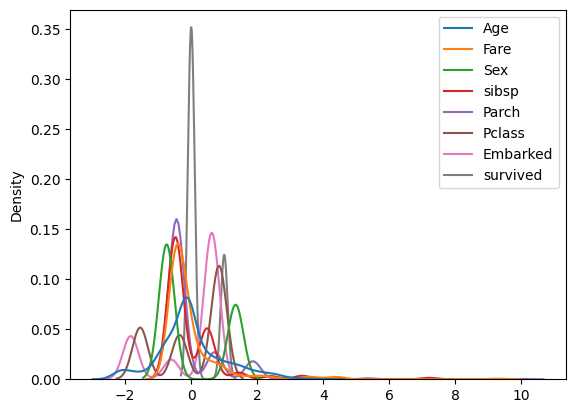

In [54]:
sns.kdeplot(data=df)

In [55]:
from sklearn.model_selection import train_test_split

# Features (X) aur Target (y)
X = df.iloc[:, :-1]  
y = df.iloc[:, -1]    

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      
    random_state=42     
)


In [56]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [57]:
pred=lr.predict(X_test)

In [71]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,recall_score

accuracy = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred)
cr = classification_report(y_test, pred)

In [59]:
print("Accuracy",accuracy)
print("confusion_matrix",cm)
print("classification_report",cr)


Accuracy 0.767175572519084
confusion_matrix [[174  15]
 [ 46  27]]
classification_report               precision    recall  f1-score   support

           0       0.79      0.92      0.85       189
           1       0.64      0.37      0.47        73

    accuracy                           0.77       262
   macro avg       0.72      0.65      0.66       262
weighted avg       0.75      0.77      0.74       262



In [75]:
recall = recall_score(y_test, pred)

print("Recall:", recall)

Recall: 0.3698630136986301


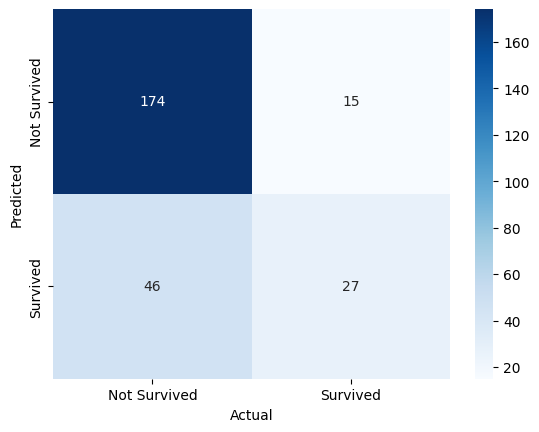

In [60]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=["Not Survived","Survived"],
    yticklabels=["Not Survived","Survived"])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [61]:
TN, FP, FN, TP = confusion_matrix(y_test, pred).ravel()

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

TN: 174
FP: 15
FN: 46
TP: 27


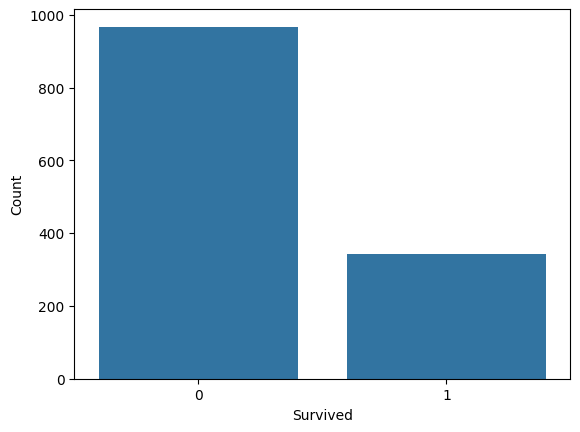

In [63]:
sns.countplot(x='survived', data=df)
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

Classes were Imbalance Thats why the recall score were only 34%, but after appllying smote the recall will increase  

In [64]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [68]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_smote, y_train_smote)
pred_smote=lr.predict(X_test)

In [ ]:
#After Balancing Classes 
accuracy_smote = accuracy_score(y_test, pred_smote)
cm_smote = confusion_matrix(y_test, pred_smote)
cr_smote = classification_report(y_test, pred_smote)
print("Accuracy",accuracy_smote)
print("confusion_matrix",cm_smote)
print("classification_report",cr_smote)

Accuracy 0.7404580152671756
confusion_matrix [[138  51]
 [ 17  56]]
classification_report               precision    recall  f1-score   support

           0       0.89      0.73      0.80       189
           1       0.52      0.77      0.62        73

    accuracy                           0.74       262
   macro avg       0.71      0.75      0.71       262
weighted avg       0.79      0.74      0.75       262



In [73]:
recall = recall_score(y_test, pred_smote)

print("Recall:", recall)

Recall: 0.7671232876712328


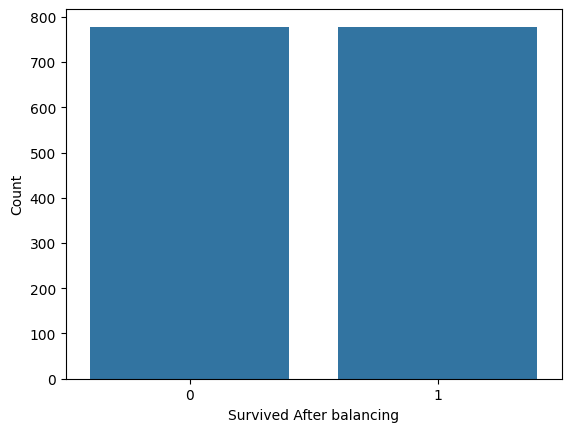

In [80]:
sns.countplot(x=y_train_smote)
plt.xlabel("Survived After balancing")
plt.ylabel("Count")
plt.show()